# 06 - Working with the minute lake

The full-market minute lake holds **7.04 billion rows in 220 GB**. Nothing in it can be loaded
whole, and every useful question has a cheap answer if you read it the way it is laid out.

This notebook covers:

1. The two lake **layouts** and why the minute lake uses the market one.
2. The **`.idx.parquet` sidecar**, which is what makes single-symbol reads fast.
3. Measured **costs** for the reads you will actually do.
4. Two pieces of genuine EDA: the **intraday volume profile** and **bar coverage**.
5. What the adjustment looks like **inside a trading day** across a split.

Cost: two to three minutes, and it never reads more than a handful of day files.

## 1. Configuration

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from polygon_ingest.lake_io import detect_layout, load_polygonio_lake, read_day_index

LAKE = Path(os.environ.get("POLYGON_LAKE_ROOT", Path.home() / "local" / "parquet_lake"))
MIN_MARKET = LAKE / "minute_adj" / "all_adjusted"              # every ticker, one file per session
MIN_TICKER = LAKE / "minute_adj" / "spx_ndx_combined_adjusted"  # 517 tickers, one file per ticker-day
MIN_RAW = LAKE / "minute" / "all"

plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
for p in (MIN_MARKET, MIN_TICKER, MIN_RAW):
    print(f"{'ok ' if p.is_dir() else 'MISSING'} {p}")

ok  /Users/mengren/local/parquet_lake/minute_adj/all_adjusted
ok  /Users/mengren/local/parquet_lake/minute_adj/spx_ndx_combined_adjusted
ok  /Users/mengren/local/parquet_lake/minute/all


## 2. Two layouts, one reader

The pipeline writes either layout and the loaders detect which one they are looking at, so
research code does not need to care.

In [2]:
def describe(root: Path, n: int = 2) -> dict:
    files = [p for p in root.rglob("*.parquet") if not p.name.endswith(".idx.parquet")]
    return {"layout": detect_layout(root), "data files": f"{len(files):,}",
            "sidecars": f"{len(list(root.rglob('*.idx.parquet'))):,}",
            "example path": str(files[len(files) // 2].relative_to(root))}

pd.DataFrame({"full market": describe(MIN_MARKET), "517 tickers": describe(MIN_TICKER)})

,full market,517 tickers
layout,market,ticker
data files,"5,517","2,437,682"
sidecars,"5,517",0
example path,2009/11/19.parquet,AIG/2025/03/12.parquet


The arithmetic behind the choice: the full market has about 33,600 symbols over 5,517 sessions.
One file per ticker-day would be tens of millions of files, most of them a few kilobytes. The
market layout writes **one file per session** instead, sorted ticker-major in 128k-row row
groups, and adds a sidecar naming each ticker's row range.

In [3]:
pd.DataFrame([
    {"layout": "ticker", "files": "2,437,682", "what one file holds": "one ticker, one day",
     "best for": "long history of a few symbols"},
    {"layout": "market", "files": "5,517", "what one file holds": "every ticker, one day",
     "best for": "cross-section on given days, and anything whole-market"},
]).set_index("layout")

,files,what one file holds,best for
layout,,,
ticker,"2,437,682","one ticker, one day",long history of a few symbols
market,"5,517","every ticker, one day","cross-section on given days, and anything whol..."


## 3. The sidecar

Next to every `<DD>.parquet` sits a `<DD>.idx.parquet` holding, per ticker, the first and last
close, the row count and the **row range** inside the day file. It is tiny and answers many
questions without opening the data file at all.

In [4]:
day_files = sorted(p for p in (MIN_MARKET / "2024" / "06").glob("*.parquet") if not p.name.endswith(".idx.parquet"))
probe = day_files[0]
idx = read_day_index(probe)
print(f"{probe.relative_to(MIN_MARKET)}: {pq.ParquetFile(probe).metadata.num_rows:,} rows, "
      f"{probe.stat().st_size / 2**20:.0f} MB")
print(f"sidecar: {len(idx):,} tickers, {probe.with_suffix('').name}.idx.parquet "
      f"{(probe.parent / (probe.stem + '.idx.parquet')).stat().st_size / 1024:.0f} KB")
idx.set_index("ticker").loc[["AAPL", "NVDA", "SPY"]]

2024/06/03.parquet: 1,524,221 rows, 54 MB
sidecar: 10,227 tickers, 03.idx.parquet 309 KB


,first_close,last_close,n_rows,row_start,row_end
ticker,,,,,
AAPL,192.77,194.08,757,3600,4356
NVDA,1124.00,1154.00,912,959321,960232
SPY,527.58,527.53,788,1257628,1258415


`row_start` and `row_end` are why a single-symbol read is cheap: because the file is sorted by
ticker, one symbol's bars are contiguous, and parquet's row-group statistics let Arrow skip every
row group that cannot contain it.

## 4. What reads actually cost

Measured on this machine, warm cache. These are the four shapes of read worth knowing.

In [5]:
def timed(label: str, fn):
    t0 = time.perf_counter()
    out = fn()
    dt = time.perf_counter() - t0
    rows = len(out) if hasattr(out, "__len__") else 0
    return {"read": label, "seconds": round(dt, 2), "rows": f"{rows:,}"}

month = ("2024-06-01", "2024-06-28")
results = [
    timed("one symbol, one month, market layout",
          lambda: load_polygonio_lake(["NVDA"], *month, MIN_MARKET, granularity="minute")),
    timed("one symbol, one month, ticker layout",
          lambda: load_polygonio_lake(["NVDA"], *month, MIN_TICKER, granularity="minute")),
    timed("50 symbols, one month, market layout",
          lambda: load_polygonio_lake(sorted(idx["ticker"].head(50)), *month, MIN_MARKET, granularity="minute")),
    timed("every ticker, one session (whole file)", lambda: pd.read_parquet(probe)),
    timed("sidecars only, a whole month (no data pages)",
          lambda: pd.concat([read_day_index(f) for f in day_files])),
]
pd.DataFrame(results).set_index("read")

,seconds,rows
read,,
"one symbol, one month, market layout",0.20,"17,908"
"one symbol, one month, ticker layout",0.03,"17,908"
"50 symbols, one month, market layout",0.18,"175,657"
"every ticker, one session (whole file)",0.04,"1,524,221"
"sidecars only, a whole month (no data pages)",0.02,"193,538"


Two ratios matter here, not the absolute numbers.

- **One symbol** is several times faster from the ticker layout, which is exactly what that
  layout is for: the file *is* the answer, with no pruning to do.
- **Fifty symbols cost the same as one** in the market layout, because each session's file is
  opened once regardless of how many symbols you want from it. That is the crossover: past a
  couple of symbols the market layout wins, and it keeps winning all the way to the whole market.

Reading the sidecars for a whole month costs less than reading a single day file, which is why
any question about coverage or liquidity should start there.

## 5. The intraday volume profile

The classic U shape, measured across every liquid symbol on a sample of sessions. This uses the
unadjusted lake because it is about volume and time of day, not price levels.

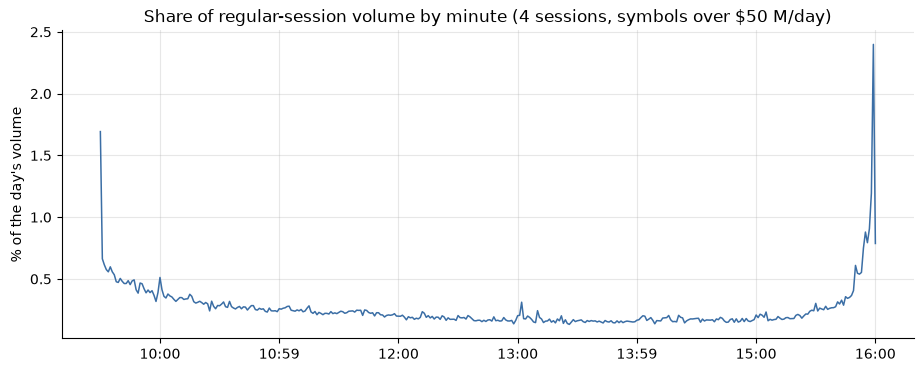

,share of session volume
first 30 minutes,15.4%
the middle 5.5 hours,68.7%
last 30 minutes,15.9%


In [6]:
sample_days = [MIN_RAW / "2024" / "06" / f"{d:02d}.parquet" for d in (3, 11, 18, 25)]
parts = []
for f in sample_days:
    d = pd.read_parquet(f, columns=["ticker", "datetime", "volume", "close"])
    d = d[d["ticker"].notna()]
    dollar = d["volume"] * d["close"]
    keep = dollar.groupby(d["ticker"]).transform("sum") > 5e7        # symbols trading over $50 M that day
    parts.append(d[keep].assign(minute=d.loc[keep, "datetime"].dt.tz_convert("US/Eastern").dt.strftime("%H:%M")))
prof = pd.concat(parts)
by_min = prof.groupby("minute")["volume"].sum()
by_min = by_min[(by_min.index >= "09:30") & (by_min.index <= "16:00")]
fig, ax = plt.subplots()
ax.plot(pd.to_datetime(by_min.index, format="%H:%M"), by_min.values / by_min.sum() * 100, lw=1.1, color="#3b6ea5")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: pd.Timestamp(x, unit="D").strftime("%H:%M")))
ax.set_title("Share of regular-session volume by minute (4 sessions, symbols over $50 M/day)")
ax.set_ylabel("% of the day's volume"); plt.show()
pd.DataFrame({"share of session volume": [
    by_min[(by_min.index >= "09:30") & (by_min.index < "10:00")].sum() / by_min.sum(),
    by_min[(by_min.index >= "10:00") & (by_min.index < "15:30")].sum() / by_min.sum(),
    by_min[(by_min.index >= "15:30")].sum() / by_min.sum()]},
    index=["first 30 minutes", "the middle 5.5 hours", "last 30 minutes"]).map("{:.1%}".format)

The opening and closing half hours carry a wildly disproportionate share of the day's volume,
which is why execution studies and any volume-weighted signal must respect time of day rather
than treating minutes as interchangeable.

## 6. Coverage: most symbols barely trade

From the sidecars alone, across a whole month.

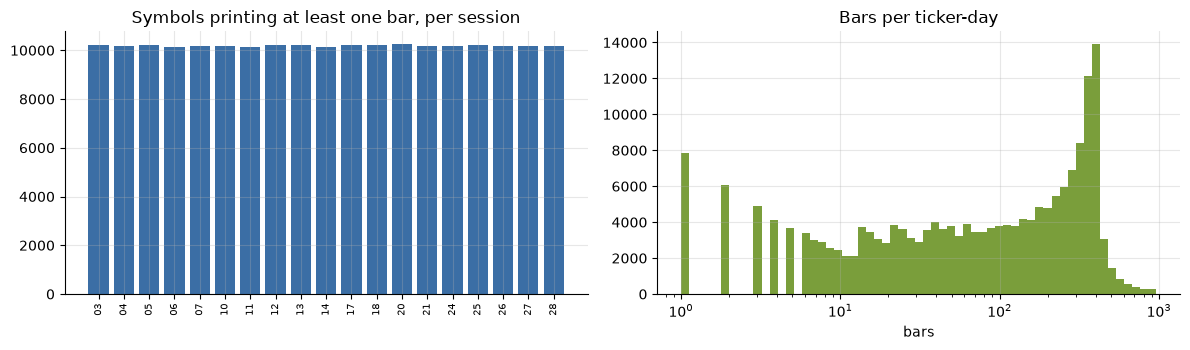

a full extended session is 960 minutes; 0.1% of ticker-days reach 900+


,count,mean,std,min,25%,50%,75%,90%,99%,max
bars per ticker-day,193538.0,145.0,156.0,1.0,14.0,73.0,266.0,382.0,565.0,960.0


In [7]:
allidx = pd.concat([read_day_index(f).assign(day=f.stem) for f in day_files])
per_day = allidx.groupby("day")["ticker"].size()
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].bar(per_day.index, per_day.values, color="#3b6ea5")
ax[0].set_title("Symbols printing at least one bar, per session"); ax[0].tick_params(axis="x", rotation=90, labelsize=7)
ax[1].hist(allidx["n_rows"], bins=np.logspace(0, np.log10(allidx["n_rows"].max()), 60), color="#7a9e3b")
ax[1].set_xscale("log"); ax[1].set_title("Bars per ticker-day"); ax[1].set_xlabel("bars")
fig.tight_layout(); plt.show()
q = allidx["n_rows"].describe(percentiles=[.25, .5, .75, .9, .99]).round(0)
print(f"a full extended session is 960 minutes; {(allidx['n_rows'] > 900).mean():.1%} of ticker-days reach 900+")
q.to_frame("bars per ticker-day").T

Half of all ticker-days carry fewer than a hundred bars. Treating the minute lake as a dense
panel is the most common way to get intraday research wrong: most cells do not exist, and
forward-filling them invents liquidity that was never there.

## 7. The adjustment, inside a trading day

NVIDIA split 10-for-1 on 10 June 2024. In the unadjusted lake the price falls by a factor of ten
overnight; in the adjusted lake the earlier bars are restated so the series is continuous.

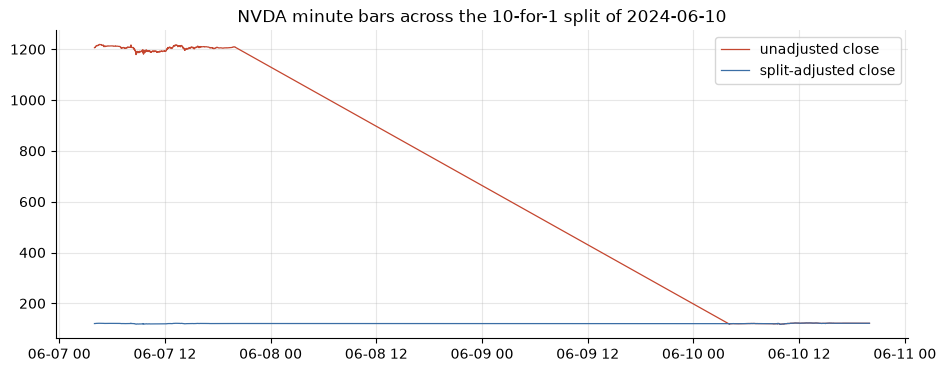

,unadjusted last close,split-adjusted last close,split factor
session,,,
2024-06-07 (before),1207.7500,120.7750,0.1
2024-06-10 (after),121.6005,121.6005,1.0


In [8]:
around = ["2024/06/07.parquet", "2024/06/10.parquet"]
raw = pd.concat([pd.read_parquet(MIN_RAW / f, filters=[("ticker", "==", "NVDA")],
                                 columns=["datetime", "close", "volume"]) for f in around])
adj = pd.concat([pd.read_parquet(MIN_MARKET / f, filters=[("ticker", "==", "NVDA")],
                                 columns=["datetime", "close", "close_split", "close_tr", "split_price_factor"]) for f in around])
raw["datetime"] = raw["datetime"].dt.tz_convert("US/Eastern").dt.tz_localize(None)
adj["datetime"] = adj["datetime"].dt.tz_localize("UTC").dt.tz_convert("US/Eastern").dt.tz_localize(None)
fig, ax = plt.subplots()
ax.plot(raw["datetime"], raw["close"], lw=.9, color="#c4462f", label="unadjusted close")
ax.plot(adj["datetime"], adj["close_split"], lw=.9, color="#3b6ea5", label="split-adjusted close")
ax.set_title("NVDA minute bars across the 10-for-1 split of 2024-06-10"); ax.legend(); plt.show()
pd.DataFrame({
    "session": ["2024-06-07 (before)", "2024-06-10 (after)"],
    "unadjusted last close": [raw[raw["datetime"] < "2024-06-08"]["close"].iloc[-1],
                              raw[raw["datetime"] >= "2024-06-10"]["close"].iloc[-1]],
    "split-adjusted last close": [adj[adj["datetime"] < "2024-06-08"]["close_split"].iloc[-1],
                                  adj[adj["datetime"] >= "2024-06-10"]["close_split"].iloc[-1]],
    "split factor": [adj[adj["datetime"] < "2024-06-08"]["split_price_factor"].iloc[-1],
                     adj[adj["datetime"] >= "2024-06-10"]["split_price_factor"].iloc[-1]],
}).set_index("session").round(4)

The factor is `0.1` on the earlier session and `1.0` afterwards, so the adjusted series has no
artificial 90% drop. Every minute bar of the day carries the same factor, which is what makes
intraday returns computed across a split correct rather than catastrophic.

## 8. Rules of thumb

- **Never** `pd.read_parquet` the minute lake root. Select a date range and a ticker list, and let
  `load_polygonio_lake` prune.
- For structural questions, read the **sidecars**. A month of them is under a megabyte and
  answers coverage, liquidity screening and first/last price without touching a data page.
- Reading many symbols on the same days costs the same as reading one, so batch a cross-section
  into a single call instead of looping per ticker. Conversely, for a long history of one or two
  symbols, prefer a ticker-layout lake if you have one.
- Treat the panel as **sparse**. Half of all ticker-days have under a hundred bars.
- Use `close_split` or `close_tr` for anything spanning a corporate action, and remember the
  adjusted lakes store tz-naive UTC while the unadjusted lakes store tz-aware US/Eastern.